In [35]:
import os
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


In [36]:
PROBLEM = "tgv_u"

def simple_true(x, y, t):
    return np.sin(x) * np.cos(y) * np.exp(-5.0 * t)

def tgv_fields(x, y, t, k=1.0, nu=1.0):
    decay_uv = np.exp(-2.0 * nu * k**2 * t)
    decay_p  = np.exp(-4.0 * nu * k**2 * t)

    u = -np.cos(k * x) * np.sin(k * y) * decay_uv
    v =  np.sin(k * x) * np.cos(k * y) * decay_uv
    p = -0.25 * (np.cos(2.0 * k * x) + np.cos(2.0 * k * y)) * decay_p
    ke = u**2 + v**2
    return u, v, p, ke

def scalar_true(x, y, t, problem=PROBLEM):
    if problem == "simple":
        return simple_true(x, y, t)

    u, v, p, ke = tgv_fields(x, y, t)

    if problem == "tgv_u":
        return u
    elif problem == "tgv_v":
        return v
    elif problem == "tgv_p":
        return p
    elif problem == "tgv_ke":
        return ke
    else:
        raise ValueError("Unknown PROBLEM. Use 'simple', 'tgv_u', 'tgv_v', 'tgv_p', or 'tgv_ke'.")

In [37]:
class MLP(nn.Module):
  def __init__(self, input_size=400, hidden_size=512, depth=5, output_size=400, act=nn.Tanh()):
    super().__init__()
    layers = []
    layers.append(nn.Linear(input_size, hidden_size))
    layers.append(act)
    for _ in range(depth - 2):
      layers.append(nn.Linear(hidden_size, hidden_size))
      layers.append(act)
    layers.append(nn.Linear(hidden_size, output_size))
    self.net = nn.Sequential(*layers)

  def forward(self, x):
    return self.net(x)

In [38]:
Nx = Ny = Nt = 20

epochs = 1000
lr = 1e-4
weight_decay = 1e-5
PRINT_EVERY = 100

TRAIN_MODEL = True
LOAD_PRETRAINED_MODEL = False

SAVE_DIR = f"standardnn_outputs_{PROBLEM}"
HEATMAP_DIR = os.path.join(SAVE_DIR, "heatmaps")
MODEL_PATH = os.path.join(SAVE_DIR, f"standardnn_model_{PROBLEM}.pth")
BEST_MODEL_PATH = os.path.join(SAVE_DIR, f"standardnn_best_model_{PROBLEM}.pth")
LOG_PATH = os.path.join(SAVE_DIR, f"logs_{PROBLEM}.npz")
RESULTS_TXT_PATH = os.path.join(SAVE_DIR, f"final_results_{PROBLEM}.txt")
ZIP_PATH = f"standardnn_outputs_{PROBLEM}.zip"

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(HEATMAP_DIR, exist_ok=True)
os.makedirs(os.path.join(HEATMAP_DIR, "assimilation"), exist_ok=True)
os.makedirs(os.path.join(HEATMAP_DIR, "forecasting"), exist_ok=True)
os.makedirs(os.path.join(HEATMAP_DIR, "ood"), exist_ok=True)

In [39]:
if PROBLEM == "simple":

    x_train = np.linspace(0.0, 1.0, Nx)
    y_train = np.linspace(0.0, 1.0, Ny)


    dx = 1.0 / (Nx - 1)
    dy = 1.0 / (Ny - 1)
    x_assim = np.linspace(0.0, 1.0, Nx, endpoint=False) + 0.5 * dx
    y_assim = np.linspace(0.0, 1.0, Ny, endpoint=False) + 0.5 * dy


    x_ood = np.linspace(1.0, 2.0, Nx)
    y_ood = np.linspace(1.0, 2.0, Ny)
    t_ood = np.linspace(1.0,2.0,Nt)

else:
    x_train = np.linspace(0.0, 2.0 * np.pi, Nx)
    y_train = np.linspace(0.0, 2.0 * np.pi, Ny)

 
    shift_x = (2.0 * np.pi) / (2 * Nx)
    shift_y = (2.0 * np.pi) / (2 * Ny)
    x_assim = (np.linspace(0.0, 2.0 * np.pi, Nx, endpoint=False) + shift_x) % (2.0 * np.pi)
    y_assim = (np.linspace(0.0, 2.0 * np.pi, Ny, endpoint=False) + shift_y) % (2.0 * np.pi)


    x_ood = np.linspace(0.5, 2.0 * np.pi + 0.5, Nx)
    y_ood = np.linspace(0.5, 2.0 * np.pi + 0.5, Ny)
    t_ood = np.linspace(0.5, 2.0 * np.pi + 0.5, Ny)

t_train = np.linspace(0.0, 1.0, Nt)

dt = t_train[1] - t_train[0]
t_forecast = t_train[-1] + dt * np.arange(1, Nt + 1)

In [40]:
def build_field_tensor(xvals, yvals, tvals, problem=PROBLEM):
    Xg, Yg = np.meshgrid(xvals, yvals, indexing="ij")
    out = np.zeros((len(tvals), len(xvals), len(yvals)), dtype=np.float32)
    for k, tk in enumerate(tvals):
        out[k] = scalar_true(Xg, Yg, tk, problem=problem).astype(np.float32)
    return torch.tensor(out, dtype=torch.float32, device=device)


def build_one_step_dataset(xvals, yvals, tvals, problem=PROBLEM):
    u_all = build_field_tensor(xvals, yvals, tvals, problem=problem)

    inputs = []
    targets = []

    for k in range(len(tvals) - 1):
        inputs.append(u_all[k].reshape(-1))
        targets.append(u_all[k + 1].reshape(-1))

    inputs = torch.stack(inputs).to(device)
    targets = torch.stack(targets).to(device)

    return u_all, inputs, targets


u_train_all, inputs_train, targets_train = build_one_step_dataset(
    x_train, y_train, t_train, problem=PROBLEM
)

u_assim_all, inputs_test_assim, targets_test_assim = build_one_step_dataset(
    x_assim, y_assim, t_train, problem=PROBLEM
)

u_ood_all, inputs_test_ood, targets_test_ood = build_one_step_dataset(
    x_ood, y_ood, t_train, problem=PROBLEM
)


u_forecast_all = build_field_tensor(x_train, y_train, t_forecast, problem=PROBLEM)
u0_forecast = u_forecast_all[0].reshape(-1)

targets_test_forecast = []
for k in range(Nt - 1):
    targets_test_forecast.append(u_forecast_all[k + 1].reshape(-1))
targets_test_forecast = torch.stack(targets_test_forecast).to(device)

In [41]:
model = MLP(
    input_size=Nx * Ny,
    hidden_size=512,
    depth=5,
    output_size=Nx * Ny,
    act=nn.Tanh()
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

def eval_test_mse_assimilation():
    model.eval()
    total = 0.0
    with torch.no_grad():
        for k in range(Nt - 1):
            pred = model(inputs_test_assim[k].unsqueeze(0)).squeeze(0)
            total += criterion(pred, targets_test_assim[k]).item()
    return total / (Nt - 1)


def eval_test_mse_forecasting():
    model.eval()
    total = 0.0
    with torch.no_grad():
        u_hat = u0_forecast.clone()
        for k in range(Nt - 1):
            pred = model(u_hat.unsqueeze(0)).squeeze(0)
            total += criterion(pred, targets_test_forecast[k]).item()
            u_hat = pred.detach()
    return total / (Nt - 1)


def eval_test_mse_ood():
    model.eval()
    total = 0.0
    with torch.no_grad():
        for k in range(Nt - 1):
            pred = model(inputs_test_ood[k].unsqueeze(0)).squeeze(0)
            total += criterion(pred, targets_test_ood[k]).item()
    return total / (Nt - 1)

In [42]:
train_log = []
assim_log = []
forecast_log = []
ood_log = []

best_forecast_mse = float("inf")
best_epoch = 0

if LOAD_PRETRAINED_MODEL and os.path.exists(BEST_MODEL_PATH):
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from: {BEST_MODEL_PATH}")

    if os.path.exists(LOG_PATH):
        logs = np.load(LOG_PATH)
        train_log = list(logs["train_log"])
        assim_log = list(logs["assim_log"])
        forecast_log = list(logs["forecast_log"])
        ood_log = list(logs["ood_log"])
        print(f"Loaded logs from: {LOG_PATH}")

elif TRAIN_MODEL:
    for epoch in range(1, epochs + 1):
        model.train()
        total_train = 0.0

        for k in range(Nt - 1):
            optimizer.zero_grad()
            pred = model(inputs_train[k].unsqueeze(0)).squeeze(0)
            loss = criterion(pred, targets_train[k])
            loss.backward()
            optimizer.step()
            total_train += loss.item()

        mean_train = total_train / (Nt - 1)

        mean_assim = eval_test_mse_assimilation()
        mean_forecast = eval_test_mse_forecasting()
        mean_ood = eval_test_mse_ood()

        train_log.append(mean_train)
        assim_log.append(mean_assim)
        forecast_log.append(mean_forecast)
        ood_log.append(mean_ood)

        if mean_forecast < best_forecast_mse:
            best_forecast_mse = mean_forecast
            best_epoch = epoch
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_mse": mean_train,
                "assim_mse": mean_assim,
                "forecast_mse": mean_forecast,
                "ood_mse": mean_ood,
            }, BEST_MODEL_PATH)

        if epoch % PRINT_EVERY == 0 or epoch == 1:
            print(
                f"[{PROBLEM}] Epoch {epoch:4d} | "
                f"Train {mean_train:.3e} | "
                f"Assim {mean_assim:.3e} | "
                f"Forecast {mean_forecast:.3e} | "
                f"OOD {mean_ood:.3e}"
            )

    torch.save({
        "epoch": epochs,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_log": train_log,
        "assim_log": assim_log,
        "forecast_log": forecast_log,
        "ood_log": ood_log,
    }, MODEL_PATH)

    np.savez(
        LOG_PATH,
        train_log=np.array(train_log),
        assim_log=np.array(assim_log),
        forecast_log=np.array(forecast_log),
        ood_log=np.array(ood_log),
    )

    print(f"\nSaved final model to: {MODEL_PATH}")
    print(f"Saved best model  to: {BEST_MODEL_PATH}")
    print(f"Saved logs        to: {LOG_PATH}")

else:
    raise ValueError("No model available. Set TRAIN_MODEL=True or LOAD_PRETRAINED_MODEL=True.")



[tgv_u] Epoch    1 | Train 4.648e-02 | Assim 1.110e-02 | Forecast 7.109e-03 | OOD 2.869e-02
[tgv_u] Epoch  100 | Train 7.744e-04 | Assim 1.749e-03 | Forecast 4.480e-03 | OOD 2.308e-02
[tgv_u] Epoch  200 | Train 3.496e-04 | Assim 1.404e-03 | Forecast 2.448e-03 | OOD 2.292e-02
[tgv_u] Epoch  300 | Train 7.274e-04 | Assim 1.385e-03 | Forecast 3.548e-03 | OOD 2.297e-02
[tgv_u] Epoch  400 | Train 2.797e-04 | Assim 1.321e-03 | Forecast 8.065e-04 | OOD 2.304e-02
[tgv_u] Epoch  500 | Train 2.298e-04 | Assim 1.233e-03 | Forecast 1.334e-03 | OOD 2.296e-02
[tgv_u] Epoch  600 | Train 2.253e-04 | Assim 1.238e-03 | Forecast 5.376e-04 | OOD 2.300e-02
[tgv_u] Epoch  700 | Train 1.972e-04 | Assim 1.188e-03 | Forecast 8.568e-04 | OOD 2.296e-02
[tgv_u] Epoch  800 | Train 6.733e-04 | Assim 9.743e-04 | Forecast 9.663e-06 | OOD 2.258e-02
[tgv_u] Epoch  900 | Train 1.729e-04 | Assim 1.154e-03 | Forecast 5.542e-04 | OOD 2.293e-02
[tgv_u] Epoch 1000 | Train 8.554e-05 | Assim 1.011e-03 | Forecast 1.860e-03 | OO

In [43]:
if os.path.exists(BEST_MODEL_PATH):
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Using best saved model from epoch {checkpoint.get('epoch', 'unknown')}")

Using best saved model from epoch 291


In [44]:
print(f"\nFinal Results (Standard NN | {PROBLEM})")

best_train_mse = float(min(train_log)) if len(train_log) > 0 else float("nan")
best_train_epoch = 1 + int(np.argmin(train_log)) if len(train_log) > 0 else -1
final_train_mse = float(train_log[-1]) if len(train_log) > 0 else float("nan")

best_assim_mse = float(min(assim_log)) if len(assim_log) > 0 else float("nan")
best_assim_epoch = 1 + int(np.argmin(assim_log)) if len(assim_log) > 0 else -1
final_assim_mse = float(assim_log[-1]) if len(assim_log) > 0 else float("nan")

best_forecast_mse = float(min(forecast_log)) if len(forecast_log) > 0 else float("nan")
best_forecast_epoch = 1 + int(np.argmin(forecast_log)) if len(forecast_log) > 0 else -1
final_forecast_mse = float(forecast_log[-1]) if len(forecast_log) > 0 else float("nan")

best_ood_mse = float(min(ood_log)) if len(ood_log) > 0 else float("nan")
best_ood_epoch = 1 + int(np.argmin(ood_log)) if len(ood_log) > 0 else -1
final_ood_mse = float(ood_log[-1]) if len(ood_log) > 0 else float("nan")

print("TRAINING")
print(f"Best epoch      : {best_train_epoch}")
print(f"Best Train MSE  : {best_train_mse:.6e}")
print(f"Final Train MSE : {final_train_mse:.6e}\n")

print("ASSIMILATION")
print(f"Best epoch      : {best_assim_epoch}")
print(f"Best Test MSE   : {best_assim_mse:.6e}")
print(f"Final Test MSE  : {final_assim_mse:.6e}\n")

print("FORECASTING")
print(f"Best epoch      : {best_forecast_epoch}")
print(f"Best Test MSE   : {best_forecast_mse:.6e}")
print(f"Final Test MSE  : {final_forecast_mse:.6e}\n")

print("OOD")
print(f"Best epoch      : {best_ood_epoch}")
print(f"Best Test MSE   : {best_ood_mse:.6e}")
print(f"Final Test MSE  : {final_ood_mse:.6e}\n")


with open(RESULTS_TXT_PATH, "w") as f:
    f.write(f"Final Results (Standard NN | {PROBLEM})\n\n")

    f.write("TRAINING\n")
    f.write(f"Best epoch      : {best_train_epoch}\n")
    f.write(f"Best Train MSE  : {best_train_mse:.6e}\n")
    f.write(f"Final Train MSE : {final_train_mse:.6e}\n\n")

    f.write("ASSIMILATION\n")
    f.write(f"Best epoch      : {best_assim_epoch}\n")
    f.write(f"Best Test MSE   : {best_assim_mse:.6e}\n")
    f.write(f"Final Test MSE  : {final_assim_mse:.6e}\n\n")

    f.write("FORECASTING\n")
    f.write(f"Best epoch      : {best_forecast_epoch}\n")
    f.write(f"Best Test MSE   : {best_forecast_mse:.6e}\n")
    f.write(f"Final Test MSE  : {final_forecast_mse:.6e}\n\n")

    f.write("OOD\n")
    f.write(f"Best epoch      : {best_ood_epoch}\n")
    f.write(f"Best Test MSE   : {best_ood_mse:.6e}\n")
    f.write(f"Final Test MSE  : {final_ood_mse:.6e}\n")

print(f"Saved results summary to: {RESULTS_TXT_PATH}")



Final Results (Standard NN | tgv_u)
TRAINING
Best epoch      : 984
Best Train MSE  : 6.566995e-05
Final Train MSE : 8.554466e-05

ASSIMILATION
Best epoch      : 800
Best Test MSE   : 9.742553e-04
Final Test MSE  : 1.010618e-03

FORECASTING
Best epoch      : 291
Best Test MSE   : 6.947133e-06
Final Test MSE  : 1.860332e-03

OOD
Best epoch      : 427
Best Test MSE   : 2.242578e-02
Final Test MSE  : 2.272587e-02

Saved results summary to: standardnn_outputs_tgv_u/final_results_tgv_u.txt


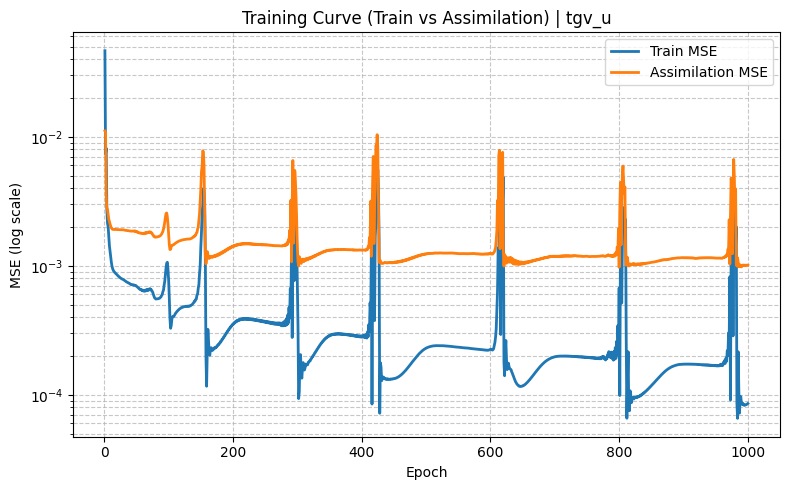

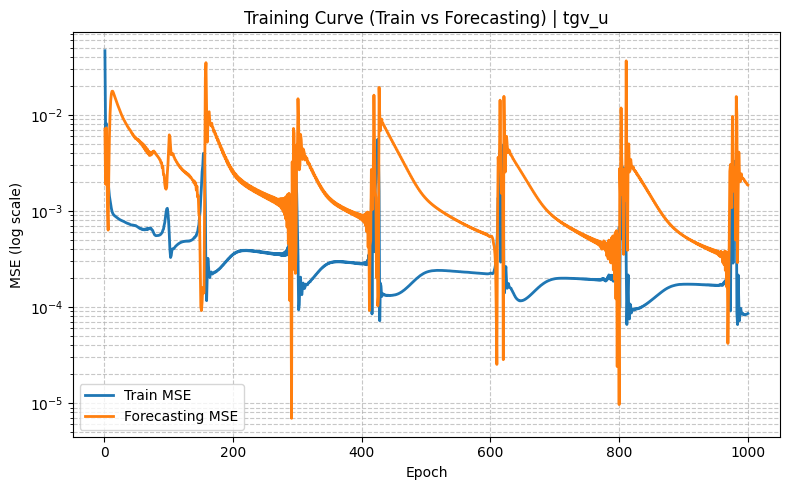

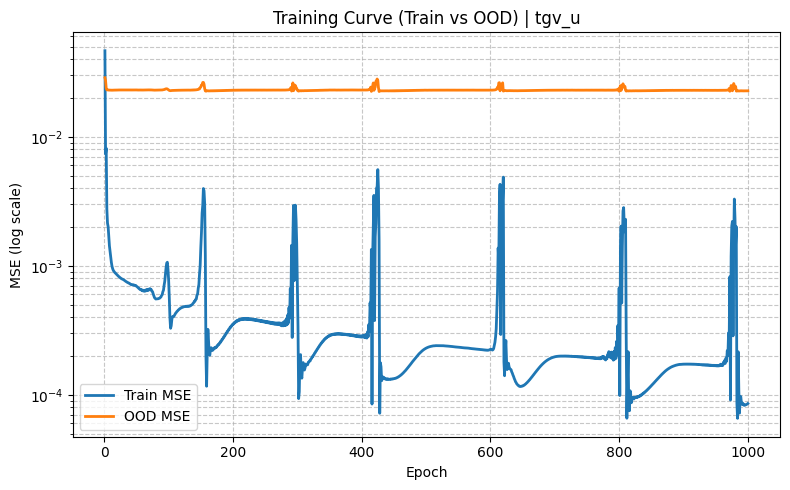

Saved separate training curves in: standardnn_outputs_tgv_u


In [45]:
if len(train_log) > 0:
    epochs_arr = np.arange(1, len(train_log) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_arr, train_log, label="Train MSE", linewidth=2)
    plt.plot(epochs_arr, assim_log, label="Assimilation MSE", linewidth=2)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (log scale)")
    plt.title(f"Training Curve (Train vs Assimilation) | {PROBLEM}")
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"curve_train_vs_assimilation_{PROBLEM}.png"), dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_arr, train_log, label="Train MSE", linewidth=2)
    plt.plot(epochs_arr, forecast_log, label="Forecasting MSE", linewidth=2)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (log scale)")
    plt.title(f"Training Curve (Train vs Forecasting) | {PROBLEM}")
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"curve_train_vs_forecasting_{PROBLEM}.png"), dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_arr, train_log, label="Train MSE", linewidth=2)
    plt.plot(epochs_arr, ood_log, label="OOD MSE", linewidth=2)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (log scale)")
    plt.title(f"Training Curve (Train vs OOD) | {PROBLEM}")
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"curve_train_vs_ood_{PROBLEM}.png"), dpi=300)
    plt.show()

    print("Saved separate training curves in:", SAVE_DIR)


In [46]:
model.eval()
with torch.no_grad():
    assim_preds_all = []
    for k in range(Nt - 1):
        pred = model(inputs_test_assim[k].unsqueeze(0)).squeeze(0)
        assim_preds_all.append(pred)
    assim_preds_all = torch.stack(assim_preds_all)

    forecast_preds_all = []
    u_hat = u0_forecast.clone()
    for k in range(Nt - 1):
        pred = model(u_hat.unsqueeze(0)).squeeze(0)
        forecast_preds_all.append(pred)
        u_hat = pred.detach()
    forecast_preds_all = torch.stack(forecast_preds_all)

    ood_preds_all = []
    for k in range(Nt - 1):
        pred = model(inputs_test_ood[k].unsqueeze(0)).squeeze(0)
        ood_preds_all.append(pred)
    ood_preds_all = torch.stack(ood_preds_all)


def plot_transition_assimilation(k, save=True, show=False):
    pred_img = assim_preds_all[k].detach().cpu().numpy().reshape(Nx, Ny)
    true_img = targets_test_assim[k].detach().cpu().numpy().reshape(Nx, Ny)
    err_img = np.abs(pred_img - true_img)

    vmin = min(true_img.min(), pred_img.min())
    vmax = max(true_img.max(), pred_img.max())
    err_vmax = max(err_img.max(), 1e-12)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(true_img.T, origin="lower", vmin=vmin, vmax=vmax)
    plt.title(f"Assim True t={t_train[k+1]:.3f}")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(pred_img.T, origin="lower", vmin=vmin, vmax=vmax)
    plt.title("Assim Predicted")
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(err_img.T, origin="lower", vmin=0.0, vmax=err_vmax)
    plt.title("Abs Error")
    plt.colorbar()

    plt.suptitle(f"ASSIMILATION | input t={t_train[k]:.3f} -> t={t_train[k+1]:.3f} | {PROBLEM}")
    plt.tight_layout()

    if save:
        path = os.path.join(HEATMAP_DIR, "assimilation", f"{PROBLEM}_assimilation_step_{k:02d}.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()


def plot_transition_forecasting(k, save=True, show=False):
    pred_img = forecast_preds_all[k].detach().cpu().numpy().reshape(Nx, Ny)
    true_img = targets_test_forecast[k].detach().cpu().numpy().reshape(Nx, Ny)
    err_img = np.abs(pred_img - true_img)

    vmin = min(true_img.min(), pred_img.min())
    vmax = max(true_img.max(), pred_img.max())
    err_vmax = max(err_img.max(), 1e-12)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(true_img.T, origin="lower", vmin=vmin, vmax=vmax)
    plt.title(f"Forecast True t={t_forecast[k+1]:.3f}")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(pred_img.T, origin="lower", vmin=vmin, vmax=vmax)
    plt.title("Forecast Predicted (rollout)")
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(err_img.T, origin="lower", vmin=0.0, vmax=err_vmax)
    plt.title("Abs Error")
    plt.colorbar()

    plt.suptitle(f"FORECASTING | input t={t_forecast[k]:.3f} -> t={t_forecast[k+1]:.3f} | step k={k} | {PROBLEM}")
    plt.tight_layout()

    if save:
        path = os.path.join(HEATMAP_DIR, "forecasting", f"{PROBLEM}_forecasting_step_{k:02d}.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()


def plot_transition_ood(k, save=True, show=False):
    pred_img = ood_preds_all[k].detach().cpu().numpy().reshape(Nx, Ny)
    true_img = targets_test_ood[k].detach().cpu().numpy().reshape(Nx, Ny)
    err_img = np.abs(pred_img - true_img)

    vmin = min(true_img.min(), pred_img.min())
    vmax = max(true_img.max(), pred_img.max())
    err_vmax = max(err_img.max(), 1e-12)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(true_img.T, origin="lower", vmin=vmin, vmax=vmax)
    plt.title(f"OOD True t={t_train[k+1]:.3f}")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(pred_img.T, origin="lower", vmin=vmin, vmax=vmax)
    plt.title("OOD Predicted")
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(err_img.T, origin="lower", vmin=0.0, vmax=err_vmax)
    plt.title("Abs Error")
    plt.colorbar()

    if PROBLEM == "simple":
        domain_text = "domain x,y in [1,2]"
    else:
        domain_text = "shifted periodic-style OOD domain"

    plt.suptitle(f"OOD | input t={t_train[k]:.3f} -> t={t_train[k+1]:.3f} | {domain_text} | {PROBLEM}")
    plt.tight_layout()

    if save:
        path = os.path.join(HEATMAP_DIR, "ood", f"{PROBLEM}_ood_step_{k:02d}.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close()


for k in range(Nt - 1):
    plot_transition_assimilation(k, save=True, show=False)
    plot_transition_forecasting(k, save=True, show=False)
    plot_transition_ood(k, save=True, show=False)

print(f"Saved all heatmaps under: {HEATMAP_DIR}")

Saved all heatmaps under: standardnn_outputs_tgv_u/heatmaps


In [47]:
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(SAVE_DIR):
        for file in files_in_dir:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, start=os.path.dirname(SAVE_DIR))
            zipf.write(full_path, arcname=arcname)

print(f"Created zip archive: {ZIP_PATH}")

Created zip archive: standardnn_outputs_tgv_u.zip
